In [1]:
import pandas as pd

In [2]:
#Load Excel file with pandas
df = pd.read_excel("Online Retail.xlsx")

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
# Display the first 5 rows of the dataset.
# This lets us see what an actual transaction record looks like.
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
# Count how many missing values (NaN) are present in each column.
# This helps us identify which fields may need cleaning before analysis.
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Count the number of unique customers with an identifiable CustomerID.
# This tells us how many different customers are available for customer-level analysis.
df["CustomerID"].nunique()

4372

In [10]:
# Show summary statistics for Quantity.
# This helps us understand the minimum, typical, and maximum quantities
# before we decide how to handle unusual values.
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [11]:
# Count transaction rows where Quantity is negative.
# Negative quantities may represent returns or cancelled transactions,
# so we inspect them before deciding how to handle them.
(df["Quantity"] < 0).sum()

np.int64(10624)

In [12]:
# Count how many transaction rows have an InvoiceNo
# beginning with "C".
# We are checking whether the negative-quantity records
# correspond to cancellation transactions.
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [13]:
# Count the number of distinct invoices whose InvoiceNo starts with "C".
# This is different from counting rows because one invoice can contain
# multiple product lines.
df.loc[
    df["InvoiceNo"].astype(str).str.startswith("C"),
    "InvoiceNo"
].nunique()

3836

In [14]:
# Find negative-quantity rows whose InvoiceNo does NOT start with "C".
# This checks whether there are returns/reversals that are not marked
# with a cancellation-style invoice number.
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].shape

(1336, 8)

In [15]:
# Display a few negative-quantity rows whose InvoiceNo does NOT start with "C".
# We are inspecting these records before deciding how they should be handled.
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [16]:
# Count negative-quantity rows that do NOT have a "C" invoice number
# but still have an identifiable CustomerID.
#
# This helps us determine whether these records could affect
# customer-level RFM analysis.
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C")) &
    (df["CustomerID"].notna())
].shape

(0, 8)

In [17]:
# Count transactions where Quantity is exactly 0.
# A zero quantity does not represent an actual purchase,
# so we need to know whether such records exist.
(df["Quantity"] == 0).sum()

np.int64(0)

In [18]:
# Show summary statistics for UnitPrice.
# This helps us understand the typical price and identify
# unusually low or high values before cleaning.
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [19]:
# Find transactions where UnitPrice is negative.
# A negative price is unusual for a normal sale, so we inspect
# these records before deciding how to handle them.
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [20]:
# Count transactions where UnitPrice is exactly 0.
# Zero-price transactions may represent free items or unusual records,
# so we inspect them before deciding how to handle them.
(df["UnitPrice"] == 0).sum()

np.int64(2515)

In [21]:
# Display the first 20 transactions where UnitPrice is 0.
# We want to understand what kinds of zero-price records are present
# before deciding whether any should be excluded.
df[df["UnitPrice"] == 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [22]:
# Count zero-price transactions that have an identifiable CustomerID.
# These are the zero-price records that could potentially affect
# customer-level RFM analysis.
df[
    (df["UnitPrice"] == 0) &
    (df["CustomerID"].notna())
].shape

(40, 8)

In [23]:
# Store the zero-price transactions that have a valid CustomerID.
# We will inspect these records because they are the only
# zero-price rows that could affect customer-level RFM.
zero_price_customers = df[
    (df["UnitPrice"] == 0) &
    (df["CustomerID"].notna())
]

# Display all of them so we can understand their pattern.
zero_price_customers

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [24]:
# Get the unique InvoiceNo + CustomerID combinations
# for the zero-price transactions that have a CustomerID.
zero_price_invoice_check = zero_price_customers[
    ["InvoiceNo", "CustomerID"]
].drop_duplicates()

# For each zero-price invoice, check whether the same invoice
# also contains at least one item with:
#   Quantity > 0
#   UnitPrice > 0
#
# True  = invoice also contains a paid item
# False = invoice contains only zero-price items
zero_price_invoice_check["HasPaidItem"] = zero_price_invoice_check.apply(
    lambda row: (
        (df["InvoiceNo"] == row["InvoiceNo"]) &
        (df["CustomerID"] == row["CustomerID"]) &
        (df["Quantity"] > 0) &
        (df["UnitPrice"] > 0)
    ).any(),
    axis=1
)

# Count how many customer-invoice combinations fall into
# each category.
zero_price_invoice_check["HasPaidItem"].value_counts()

HasPaidItem
True     30
False     4
Name: count, dtype: int64

In [25]:
# Keep only the customer-invoice combinations where there was
# no paid item in the same invoice.
zero_price_only = zero_price_invoice_check[
    zero_price_invoice_check["HasPaidItem"] == False
]

# Display the actual transaction rows belonging to those invoices.
# We want to understand what these four unusual invoices contain
# before deciding how they should be treated.
df[
    (df["InvoiceNo"].isin(zero_price_only["InvoiceNo"])) &
    (df["CustomerID"].isin(zero_price_only["CustomerID"]))
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
314745,564651,23270,SET OF 2 CERAMIC PAINTED HEARTS,96,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314746,564651,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER,192,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314747,564651,22955,36 FOIL STAR CAKE CASES,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314748,564651,21786,POLKADOT RAIN HAT,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands
361825,568384,M,Manual,1,2011-09-27 09:46:00,0.0,12748.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256.0,United Kingdom


In [26]:
# Count rows that are exact duplicates of another row.
# We check this before cleaning because duplicate transactions
# could affect our RFM calculations.
df.duplicated().sum()

np.int64(5268)

In [27]:
# Display the first 10 exact duplicate rows.
# We are inspecting them before deciding whether they should be removed.
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [28]:
# Compare the number of rows before and after removing exact duplicates.
# This tells us how many records are actually duplicated.
print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df.drop_duplicates()))
print("Duplicate rows:", df.duplicated().sum())

Original rows: 541909
Rows after removing duplicates: 536641
Duplicate rows: 5268


In [29]:
# Count the number of unique invoice numbers in the dataset.
# This helps us understand how many separate orders/transactions
# are represented by the 541,909 transaction rows.
df["InvoiceNo"].nunique()

25900

In [30]:
# Count how many invoices are associated with more than one CustomerID.
# We expect an invoice to belong to a single customer.
# This check verifies that assumption before we use invoices
# to calculate Frequency.
invoice_customer_counts = (
    df.groupby("InvoiceNo")["CustomerID"]
    .nunique()
)

(invoice_customer_counts > 1).sum()

np.int64(0)

In [31]:
# Check the earliest and latest transaction dates in the dataset.
# This tells us the time period covered by the retail data
# and will later help us calculate Recency.
print("Earliest transaction:", df["InvoiceDate"].min())
print("Latest transaction:", df["InvoiceDate"].max())

Earliest transaction: 2010-12-01 08:26:00
Latest transaction: 2011-12-09 12:50:00


In [32]:
# Display the 10 transactions with the largest quantities.
# We are checking extreme values before deciding whether
# they are genuine transactions or possible data-quality issues.
df.nlargest(10, "Quantity")[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "InvoiceDate", "UnitPrice",
     "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.00,NaN,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
220843,556231,85123A,?,4000,2011-06-09 15:04:00,0.00,NaN,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom


In [33]:
# Display the 10 transactions with the highest UnitPrice.
# We are checking whether these extreme prices look like
# legitimate transactions or unusual records.
df.nlargest(10, "UnitPrice")[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "InvoiceDate", "UnitPrice",
     "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom
524602,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom
524601,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom


In [34]:
# Find the 10 highest-priced transaction lines that:
# 1. have a positive quantity,
# 2. have an identifiable customer, and
# 3. have a positive UnitPrice.
#
# These are the extreme prices that could actually affect
# our customer-level RFM analysis.
df[
    (df["Quantity"] > 0) &
    (df["CustomerID"].notna()) &
    (df["UnitPrice"] > 0)
].nlargest(10, "UnitPrice")[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "InvoiceDate", "UnitPrice",
     "CustomerID", "Country"]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536.0,France
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536.0,France
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744.0,Singapore
374542,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,15502.0,United Kingdom
297438,562946,M,Manual,1,2011-08-11 09:38:00,2500.00,15581.0,United Kingdom
144826,548813,M,Manual,1,2011-04-04 13:03:00,2382.92,12744.0,Singapore
406407,571751,M,Manual,1,2011-10-19 11:18:00,2118.74,12744.0,Singapore
144829,548820,M,Manual,1,2011-04-04 13:04:00,2053.07,12744.0,Singapore
343000,566927,M,Manual,1,2011-09-15 15:20:00,2033.10,17846.0,United Kingdom


In [35]:
# Look at common non-product / service / adjustment descriptions.
# These records can affect Monetary even though they may not represent
# an actual product purchase.
keywords = ["POSTAGE", "Manual", "AMAZON FEE", "BANK CHARGES", "BAD DEBT"]

df[
    df["Description"].fillna("").str.upper().isin(
        [k.upper() for k in keywords]
    )
]["Description"].value_counts(dropna=False)

Description
POSTAGE         1252
Manual           572
Bank Charges      37
AMAZON FEE        34
Name: count, dtype: int64

In [36]:
# Count the special/service/adjustment records that have
# an identifiable CustomerID.
#
# These are the records that could potentially affect
# customer-level RFM calculations.
special_descriptions = [
    "POSTAGE",
    "Manual",
    "Bank Charges",
    "AMAZON FEE"
]

special_records = df[
    df["Description"].fillna("").str.upper().isin(
        [x.upper() for x in special_descriptions]
    )
]

special_records["CustomerID"].notna().value_counts()

CustomerID
True     1673
False     222
Name: count, dtype: int64

In [37]:
# Identify the invoices that contain the special/service records.
special_invoices = special_records["InvoiceNo"].unique()

# For those invoices, count how many rows are normal product lines
# (i.e., descriptions other than the special/service records).
normal_product_rows = df[
    df["InvoiceNo"].isin(special_invoices) &
    (~df["Description"].fillna("").str.upper().isin(
        [x.upper() for x in special_descriptions]
    )) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

print("Special invoices:", len(special_invoices))
print("Normal product rows in those invoices:", len(normal_product_rows))

Special invoices: 1810
Normal product rows in those invoices: 31570


In [38]:
# Summarize Quantity and UnitPrice for the special/service/adjustment records.
# This helps us see whether they are normal positive charges,
# zero-price records, or negative/adjustment transactions.
special_records[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,1895.000000,1895.000000
mean,3.232190,273.027837
std,66.083544,1524.122983
min,-1350.000000,0.000000
25%,1.000000,15.000000
50%,1.000000,18.000000
75%,3.000000,28.000000
max,1600.000000,38970.000000


In [39]:
# Count special/service/adjustment records by the sign of Quantity.
# This helps us separate normal positive transactions from
# negative adjustment/return records and zero-quantity records.

special_records["Quantity"].apply(
    lambda x: "Positive" if x > 0 else "Negative" if x < 0 else "Zero"
).value_counts()

Quantity
Positive    1468
Negative     427
Name: count, dtype: int64

In [40]:
# Count transaction rows for each customer.
# This helps us understand how active customers are in the raw data
# before we build the final RFM table.
customer_transaction_counts = df.groupby("CustomerID").size()

customer_transaction_counts.describe()

count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
dtype: float64

In [41]:
# Identify customers who exist in the raw data
# but have no positive-quantity purchase.
customers_without_positive_purchase = set(
    df.loc[df["CustomerID"].notna(), "CustomerID"]
) - set(
    df.loc[df["CustomerID"].notna() & (df["Quantity"] > 0), "CustomerID"]
)

# Display a few transaction records for these customers
# so we can understand why they have no positive purchases.
df[
    df["CustomerID"].isin(customers_without_positive_purchase)
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
4306,C536760,22175,PINK OWL SOFT TOY,-1,2010-12-02 14:29:00,2.95,17547.0,United Kingdom
4307,C536760,22273,FELTCRAFT DOLL MOLLY,-3,2010-12-02 14:29:00,2.95,17547.0,United Kingdom
4876,C536814,21527,RED RETROSPOT TRADITIONAL TEAPOT,-2,2010-12-02 17:03:00,7.95,13958.0,United Kingdom
4877,C536814,72799E,IVORY PILLAR CANDLE SILVER FLOCK,-6,2010-12-02 17:03:00,2.95,13958.0,United Kingdom
4878,C536814,85066,CREAM SWEETHEART MINI CHEST,-2,2010-12-02 17:03:00,12.75,13958.0,United Kingdom
4879,C536814,21586,KINGS CHOICE GIANT TUBE MATCHES,-12,2010-12-02 17:03:00,2.55,13958.0,United Kingdom
4880,C536814,21258,VICTORIAN SEWING BOX LARGE,-1,2010-12-02 17:03:00,12.75,13958.0,United Kingdom
4886,C536818,84947,ANTIQUE SILVER TEA GLASS ENGRAVED,-1,2010-12-02 17:09:00,1.25,16995.0,United Kingdom
5232,C536850,22942,CHRISTMAS LIGHTS 10 SANTAS,-48,2010-12-03 09:47:00,7.65,14213.0,United Kingdom
5233,C536850,22689,DOORMAT MERRY CHRISTMAS RED,-50,2010-12-03 09:47:00,6.75,14213.0,United Kingdom


In [42]:
# Check all transactions belonging to customers who have
# no positive-quantity purchase.
#
# We want to verify that their records are actually
# cancellation/return-only records.
customers_without_positive_purchase = set(
    df.loc[df["CustomerID"].notna(), "CustomerID"]
) - set(
    df.loc[
        df["CustomerID"].notna() & (df["Quantity"] > 0),
        "CustomerID"
    ]
)

only_returns = df[
    df["CustomerID"].isin(customers_without_positive_purchase)
]

print(
    "Rows with negative quantity:",
    (only_returns["Quantity"] < 0).sum()
)

print(
    "Rows with C-prefixed InvoiceNo:",
    only_returns["InvoiceNo"].astype(str).str.startswith("C").sum()
)

print(
    "Total rows:",
    len(only_returns)
)

Rows with negative quantity: 88
Rows with C-prefixed InvoiceNo: 88
Total rows: 88


In [43]:
# Create a cleaned copy of the original dataset by removing
# exact duplicate rows.
#
# We keep the original df unchanged so we can always refer
# back to the raw dataset if needed.
df_cleaned = df.drop_duplicates().copy()

# Compare the size before and after duplicate removal.
print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_cleaned))
print("Rows removed:", len(df) - len(df_cleaned))

Original rows: 541909
Rows after removing duplicates: 536641
Rows removed: 5268


In [44]:
# Verify that the cleaned dataset contains no exact duplicate rows.
df_cleaned.duplicated().sum()

np.int64(0)

In [45]:
# Keep only transactions that have a CustomerID.
# We need an identifiable customer to calculate
# Recency, Frequency, and Monetary values.
df_customer = df_cleaned.dropna(subset=["CustomerID"]).copy()

# Check how many rows remain after this cleaning step.
print("Rows after removing missing CustomerID:", len(df_customer))

Rows after removing missing CustomerID: 401604


In [46]:
# Count negative-quantity transactions remaining after
# duplicate removal and CustomerID filtering.
#
# These are the negative transactions that could potentially
# affect our customer-level RFM analysis.
(df_customer["Quantity"] < 0).sum()

np.int64(8872)

In [47]:
# Count how many remaining negative-quantity rows
# have an InvoiceNo starting with "C".
#
# This verifies that the negative transactions remaining
# in our customer-level dataset are cancellation/return records.
df_customer[
    df_customer["Quantity"] < 0
]["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8872)

In [48]:
# Keep only transactions with a positive quantity.
# This removes cancellation/return transactions from our
# purchase-based RFM dataset.
df_purchases = df_customer[df_customer["Quantity"] > 0].copy()

# Check how many rows remain.
print("Rows after removing negative quantities:", len(df_purchases))

Rows after removing negative quantities: 392732


In [49]:
# Verify that the purchase dataset contains only positive quantities.
# We expect both counts to be 0.
print("Negative quantities:", (df_purchases["Quantity"] < 0).sum())
print("Zero quantities:", (df_purchases["Quantity"] == 0).sum())

Negative quantities: 0
Zero quantities: 0


In [50]:
# Count zero-price transaction lines in our current purchase dataset.
# We are checking how many remain after duplicate, CustomerID,
# and negative-quantity cleaning.
(df_purchases["UnitPrice"] == 0).sum()

np.int64(40)

In [51]:
# Identify invoices that contain at least one normal paid purchase.
# A paid purchase is defined here as:
# Quantity > 0 and UnitPrice > 0.

paid_invoices = df_purchases[
    (df_purchases["Quantity"] > 0) &
    (df_purchases["UnitPrice"] > 0)
]["InvoiceNo"].unique()

# Keep all positive-quantity rows that belong to an invoice
# containing at least one paid item.
#
# This means:
# - zero-price lines inside normal paid invoices are kept
# - zero-price-only invoices are removed
df_purchases_clean = df_purchases[
    (df_purchases["Quantity"] > 0) &
    (df_purchases["InvoiceNo"].isin(paid_invoices))
].copy()

print("Rows before zero-price handling:", len(df_purchases))
print("Rows after zero-price handling:", len(df_purchases_clean))

Rows before zero-price handling: 392732
Rows after zero-price handling: 392725


In [52]:
# Check whether any invoice in the cleaned purchase dataset
# contains only zero-price items.
#
# We expect this to return 0.
zero_price_only_remaining = (
    df_purchases_clean
    .groupby("InvoiceNo")["UnitPrice"]
    .apply(lambda x: (x == 0).all())
    .sum()
)

zero_price_only_remaining

np.int64(0)

In [53]:
# Final sanity check for the cleaned purchase dataset.
# These checks confirm that the important RFM input fields
# are in the expected state before we calculate RFM.

print("Missing CustomerID:", df_purchases_clean["CustomerID"].isna().sum())
print("Negative Quantity:", (df_purchases_clean["Quantity"] < 0).sum())
print("Zero Quantity:", (df_purchases_clean["Quantity"] == 0).sum())
print("Negative UnitPrice:", (df_purchases_clean["UnitPrice"] < 0).sum())
print("Zero UnitPrice:", (df_purchases_clean["UnitPrice"] == 0).sum())
print("Exact duplicate rows:", df_purchases_clean.duplicated().sum())

Missing CustomerID: 0
Negative Quantity: 0
Zero Quantity: 0
Negative UnitPrice: 0
Zero UnitPrice: 33
Exact duplicate rows: 0


In [54]:
# Calculate Frequency for each customer.
# We count unique InvoiceNo values because one invoice
# can contain multiple product lines.
frequency = (
    df_purchases_clean
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

# Display the first 10 customers and their purchase frequency.
frequency.head(10)

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
12352.0    8
12353.0    1
12354.0    1
12355.0    1
12356.0    3
Name: InvoiceNo, dtype: int64

In [55]:
# Calculate the total value of each transaction line.
# Quantity tells us how many units were purchased,
# while UnitPrice tells us the price of one unit.
df_purchases_clean["TotalPrice"] = (
    df_purchases_clean["Quantity"] *
    df_purchases_clean["UnitPrice"]
)

# Display the values used in the calculation for a few rows.
df_purchases_clean[
    ["Quantity", "UnitPrice", "TotalPrice"]
].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [56]:
# Calculate the total amount spent by each customer.
# We sum TotalPrice across all purchase lines belonging
# to the same CustomerID.
monetary = (
    df_purchases_clean
    .groupby("CustomerID")["TotalPrice"]
    .sum()
)

# Display the spending of the first 10 customers.
monetary.head(10)

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
12352.0     2506.04
12353.0       89.00
12354.0     1079.40
12355.0      459.40
12356.0     2811.43
Name: TotalPrice, dtype: float64

In [57]:
# Find the latest transaction date in our cleaned purchase dataset.
# This date will be the starting point for calculating customer Recency.
latest_purchase = df_purchases_clean["InvoiceDate"].max()

latest_purchase

Timestamp('2011-12-09 12:50:00')

In [58]:
# Create the reference date for Recency calculation.
# We add one day to the latest valid purchase date so that
# the most recent customer has a Recency value of 1 day.
reference_date = latest_purchase + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [59]:
# Find each customer's most recent purchase date.
# Then calculate how many days have passed between that
# purchase and our reference date.
recency = (
    df_purchases_clean
    .groupby("CustomerID")["InvoiceDate"]
    .max()
    .apply(lambda x: (reference_date - x).days)
)

# Display the Recency values for the first 10 customers.
recency.head(10)

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
12352.0     36
12353.0    204
12354.0    232
12355.0    214
12356.0     23
Name: InvoiceDate, dtype: int64

In [60]:
# Combine Recency, Frequency, and Monetary into one customer-level table.
# Each row now represents one customer.
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

# Check the shape and display the first few customers.
print("RFM shape:", rfm.shape)
rfm.head()

RFM shape: (4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [61]:
# Show summary statistics for the completed RFM table.
# This helps us understand the typical customer and identify
# skewed or extreme RFM values before scoring and clustering.
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [62]:
# Measure the skewness of each RFM variable.
# A positive skew means the distribution has a longer tail
# toward larger values.
rfm.skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

In [63]:
# Rank customers by Recency so ties can be handled consistently.
# For Recency, LOWER values are better, so the labels are reversed:
# 5 = most recent, 1 = least recent.

rfm["R_score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
)

# Display the original Recency and the new R score
# for the first few customers.
rfm[["Recency", "R_score"]].head(10)

,Recency,R_score
CustomerID,,
12346.0,326,1
12347.0,2,5
12348.0,75,2
12349.0,19,4
12350.0,310,1
12352.0,36,3
12353.0,204,1
12354.0,232,1
12355.0,214,1


In [64]:
# Create the Frequency score from 1 to 5.
# Higher Frequency is better, so:
# 1 = lowest purchase frequency
# 5 = highest purchase frequency
#
# We rank the values first so that tied Frequency values
# can still be divided into five groups.

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Display Frequency and its new score for the first 10 customers.
rfm[["Frequency", "F_score"]].head(10)

,Frequency,F_score
CustomerID,,
12346.0,1,1
12347.0,7,5
12348.0,4,4
12349.0,1,1
12350.0,1,1
12352.0,8,5
12353.0,1,1
12354.0,1,1
12355.0,1,1


In [65]:
# Create the Monetary score from 1 to 5.
# Higher spending customers receive higher scores:
# 1 = lowest spending
# 5 = highest spending
#
# We rank first so tied Monetary values can be divided
# into five groups consistently.

rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Display Monetary and its new score for the first 10 customers.
rfm[["Monetary", "M_score"]].head(10)

,Monetary,M_score
CustomerID,,
12346.0,77183.60,5
12347.0,4310.00,5
12348.0,1797.24,4
12349.0,1757.55,4
12350.0,334.40,2
12352.0,2506.04,5
12353.0,89.00,1
12354.0,1079.40,4
12355.0,459.40,2


In [66]:
# Combine the Recency, Frequency, and Monetary scores
# into a single three-digit RFM profile.
#
# Example:
# R=5, F=5, M=5 → "555"
# R=1, F=1, M=1 → "111"

rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

# Display the first 10 customers with their RFM profile.
rfm[[
    "Recency", "Frequency", "Monetary",
    "R_score", "F_score", "M_score", "RFM_Score"
]].head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112
12352.0,36,8,2506.04,3,5,5,355
12353.0,204,1,89.00,1,1,1,111
12354.0,232,1,1079.40,1,1,4,114
12355.0,214,1,459.40,1,1,2,112


In [67]:
# Count how many customers have each RFM profile.
# This helps us see which customer behavior patterns
# are most common in our dataset.
rfm["RFM_Score"].value_counts().head(20)

RFM_Score
555    347
111    184
455    172
121    154
112    127
444    111
122     90
344     87
233     87
544     85
355     84
554     82
211     82
443     78
244     71
321     68
311     68
343     67
221     65
333     64
Name: count, dtype: int64

In [68]:
# Create a simple baseline segment for customers
# who are relatively recent, frequent, and high-spending.
#
# R_score >= 4 → relatively recent
# F_score >= 4 → relatively frequent
# M_score >= 4 → relatively high spending

rfm["Segment"] = "Other"

rfm.loc[
    (rfm["R_score"].astype(int) >= 4) &
    (rfm["F_score"].astype(int) >= 4) &
    (rfm["M_score"].astype(int) >= 4),
    "Segment"
] = "High-Value Engaged"

# Count how many customers fall into this segment.
rfm["Segment"].value_counts()

Segment
Other                 3396
High-Value Engaged     942
Name: count, dtype: int64

In [69]:
# Identify customers who are no longer recent
# but still have high Frequency and Monetary scores.
#
# R_score <= 2 → not recently active
# F_score >= 4 → frequent historically
# M_score >= 4 → high spending

rfm.loc[
    (rfm["R_score"].astype(int) <= 2) &
    (rfm["F_score"].astype(int) >= 4) &
    (rfm["M_score"].astype(int) >= 4),
    "Segment"
] = "At Risk - High Value"

# Count the customers in each segment so far.
rfm["Segment"].value_counts()

Segment
Other                   3221
High-Value Engaged       942
At Risk - High Value     175
Name: count, dtype: int64

In [70]:
# Identify customers who are relatively recent
# but have purchased only a small number of times.
#
# R_score >= 4 → relatively recent
# F_score <= 2 → low purchase frequency

rfm.loc[
    (rfm["R_score"].astype(int) >= 4) &
    (rfm["F_score"].astype(int) <= 2),
    "Segment"
] = "New / Promising"

# Count customers in each baseline segment.
rfm["Segment"].value_counts()

Segment
Other                   2911
High-Value Engaged       942
New / Promising          310
At Risk - High Value     175
Name: count, dtype: int64

In [71]:
# Identify customers who are low across all three RFM dimensions.
#
# R_score <= 2 → not recently active
# F_score <= 2 → low purchase frequency
# M_score <= 2 → low spending

rfm.loc[
    (rfm["R_score"].astype(int) <= 2) &
    (rfm["F_score"].astype(int) <= 2) &
    (rfm["M_score"].astype(int) <= 2),
    "Segment"
] = "Low-Engagement"

# Show the final counts of our baseline segments so far.
rfm["Segment"].value_counts()

Segment
Other                   2086
High-Value Engaged       942
Low-Engagement           825
New / Promising          310
At Risk - High Value     175
Name: count, dtype: int64

In [72]:
# Recreate the original rule-based baseline using the RFM score rules.
# We store it separately so it cannot be overwritten by K-Means.

rfm["Baseline_Segment"] = "Other"

# High-Value Engaged
rfm.loc[
    (rfm["R_score"].astype(int) >= 4) &
    (rfm["F_score"].astype(int) >= 4) &
    (rfm["M_score"].astype(int) >= 4),
    "Baseline_Segment"
] = "High-Value Engaged"

# At Risk - High Value
rfm.loc[
    (rfm["R_score"].astype(int) <= 2) &
    (rfm["F_score"].astype(int) >= 4) &
    (rfm["M_score"].astype(int) >= 4),
    "Baseline_Segment"
] = "At Risk - High Value"

# New / Promising
rfm.loc[
    (rfm["R_score"].astype(int) >= 4) &
    (rfm["F_score"].astype(int) <= 2),
    "Baseline_Segment"
] = "New / Promising"

# Low-Engagement
rfm.loc[
    (rfm["R_score"].astype(int) <= 2) &
    (rfm["F_score"].astype(int) <= 2) &
    (rfm["M_score"].astype(int) <= 2),
    "Baseline_Segment"
] = "Low-Engagement"

# Check the recreated baseline.
rfm["Baseline_Segment"].value_counts()

Baseline_Segment
Other                   2086
High-Value Engaged       942
Low-Engagement           825
New / Promising          310
At Risk - High Value     175
Name: count, dtype: int64

In [73]:
# Create a separate dataset for K-Means.
# We use the original RFM values, not the RFM scores.
# K-Means should learn from the actual customer behavior.

rfm_model = rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]].copy()

# Display the first 5 customers.
rfm_model.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [74]:
# Import NumPy.
# NumPy provides mathematical functions such as log1p().
import numpy as np

In [75]:
# Apply log transformation to reduce the effect of extreme values.
# log1p(x) means log(1 + x).
# This is useful because our RFM variables are highly right-skewed.

rfm_log = np.log1p(rfm_model)

# Display the transformed RFM values.
rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [76]:
# Import StandardScaler from scikit-learn.
# StandardScaler puts each feature onto a comparable scale.
from sklearn.preprocessing import StandardScaler

# Create the scaler.
scaler = StandardScaler()

# Fit the scaler to our log-transformed RFM data
# and transform the values.
rfm_scaled = scaler.fit_transform(rfm_log)

# Display the first 5 rows of the scaled data.
rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

In [77]:
# Check the mean and standard deviation of each scaled RFM feature.
# After StandardScaler, the mean should be approximately 0
# and the standard deviation should be approximately 1.

print("Mean:")
print(rfm_scaled.mean(axis=0))

print("\nStandard deviation:")
print(rfm_scaled.std(axis=0))

Mean:
[-8.02595529e-17 -8.18975030e-18 -3.66900813e-16]

Standard deviation:
[1. 1. 1.]


In [78]:
# Import KMeans from scikit-learn.
from sklearn.cluster import KMeans

# Store the inertia value for each number of clusters.
inertia = []

# Test K values from 2 to 10.
for k in range(2, 11):
    
    # Create the K-Means model.
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    # Fit the model to our scaled RFM data.
    kmeans.fit(rfm_scaled)
    
    # Store the inertia for this K.
    inertia.append(kmeans.inertia_)

# Display the inertia values.
inertia

[6483.589425039294,
 4869.488628540215,
 3939.0493816391618,
 3296.708707642544,
 2855.7640680431077,
 2548.820244849562,
 2336.341053610394,
 2156.0056725213453,
 2005.7462362695562]

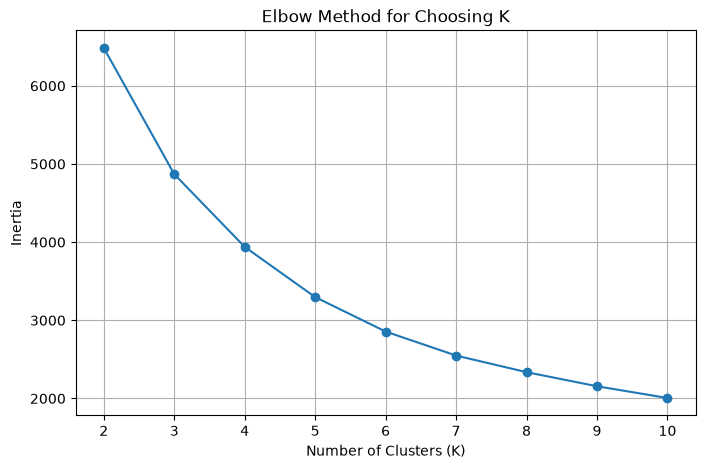

In [79]:
import matplotlib.pyplot as plt

# K values corresponding to our inertia results.
k_values = range(2, 11)

# Plot the Elbow Curve.
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [80]:
from sklearn.metrics import silhouette_score

# Store the silhouette score for each number of clusters.
silhouette_scores = []

# Test K values from 2 to 10.
for k in range(2, 11):

    # Create the K-Means model.
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Create cluster labels for each customer.
    cluster_labels = kmeans.fit_predict(rfm_scaled)

    # Calculate how well-separated the clusters are.
    score = silhouette_score(rfm_scaled, cluster_labels)

    # Store the score.
    silhouette_scores.append(score)

# Display the scores.
silhouette_scores

[0.4328265515350662,
 0.3365174636950013,
 0.33751704921261194,
 0.3162001336222631,
 0.3124091056438892,
 0.30918598433785954,
 0.30327504528060134,
 0.281084500299107,
 0.2766585172543556]

In [81]:
# Create a K-Means model with 2 clusters.
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Train the model and assign each customer to a cluster.
cluster_2 = kmeans_2.fit_predict(rfm_scaled)

# Display the first 10 cluster assignments.
cluster_2[:10]

array([1, 1, 1, 0, 0, 1, 0, 0, 0, 1], dtype=int32)

In [82]:
# Add the K=2 cluster labels to our RFM dataset.
rfm["Cluster_2"] = cluster_2

# Calculate the average RFM values for each cluster.
cluster_2_profile = (
    rfm.groupby("Cluster_2")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

# Count how many customers are in each cluster.
cluster_2_counts = rfm["Cluster_2"].value_counts().sort_index()

print("Average RFM values:")
print(cluster_2_profile)

print("\nNumber of customers:")
print(cluster_2_counts)

Average RFM values:
              Recency  Frequency     Monetary
Cluster_2                                    
0          134.091317   1.671033   495.594945
1           25.888956   8.443577  4539.603362

Number of customers:
Cluster_2
0    2672
1    1666
Name: count, dtype: int64


In [83]:
# Compare the median RFM values for the two clusters.
# Median helps us understand the "typical" customer
# without being strongly influenced by extreme values.

cluster_2_median = (
    rfm.groupby("Cluster_2")[["Recency", "Frequency", "Monetary"]]
    .median()
)

cluster_2_median

,Recency,Frequency,Monetary
Cluster_2,,,
0,96.0,1.0,363.075
1,16.0,6.0,2061.075


In [84]:
# Create a K-Means model with 3 clusters.
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train the model and assign each customer to a cluster.
cluster_3 = kmeans_3.fit_predict(rfm_scaled)

# Display the first 10 cluster assignments.
cluster_3[:10]

array([2, 0, 2, 2, 1, 0, 1, 1, 1, 2], dtype=int32)

In [85]:
# Add the K=3 cluster labels to our RFM dataset.
rfm["Cluster_3"] = cluster_3

# Calculate the average RFM values for each cluster.
cluster_3_profile = (
    rfm.groupby("Cluster_3")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

# Count the number of customers in each cluster.
cluster_3_counts = rfm["Cluster_3"].value_counts().sort_index()

print("Average RFM values:")
print(cluster_3_profile)

print("\nNumber of customers:")
print(cluster_3_counts)

Average RFM values:
              Recency  Frequency     Monetary
Cluster_3                                    
0           17.062419  13.348505  7898.462003
1          167.358440   1.352030   360.996448
2           44.199764   3.380082  1259.579412

Number of customers:
Cluster_3
0     769
1    1872
2    1697
Name: count, dtype: int64


In [86]:
# Compare the median RFM values for the three K=3 clusters.
# Median helps us understand the typical customer
# without being strongly affected by extreme values.

cluster_3_median = (
    rfm.groupby("Cluster_3")[["Recency", "Frequency", "Monetary"]]
    .median()
)

cluster_3_median

,Recency,Frequency,Monetary
Cluster_3,,,
0,9.0,10.0,3701.44
1,158.0,1.0,296.09
2,30.0,3.0,974.42


In [87]:
# Create a K-Means model with 4 clusters.
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Train the model and assign each customer to a cluster.
cluster_4 = kmeans_4.fit_predict(rfm_scaled)

# Display the first 10 cluster assignments.
cluster_4[:10]

array([3, 0, 3, 2, 1, 3, 1, 1, 1, 3], dtype=int32)

In [88]:
# Add the K=4 cluster labels to our RFM dataset.
rfm["Cluster_4"] = cluster_4

# Calculate the average RFM values for each cluster.
cluster_4_profile = (
    rfm.groupby("Cluster_4")[["Recency", "Frequency", "Monetary"]]
    .mean()
)

# Count the number of customers in each cluster.
cluster_4_counts = rfm["Cluster_4"].value_counts().sort_index()

print("Average RFM values:")
print(cluster_4_profile)

print("\nNumber of customers:")
print(cluster_4_counts)

Average RFM values:
              Recency  Frequency     Monetary
Cluster_4                                    
0           12.171108  13.751753  8088.018331
1          181.506782   1.316893   340.998626
2           17.698925   2.192354   557.322616
3           71.635506   4.078902  1801.777893

Number of customers:
Cluster_4
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


In [89]:
# Compare the median RFM values for the four K=4 clusters.
# Median helps us understand the typical customer
# without being strongly affected by extreme values.

cluster_4_median = (
    rfm.groupby("Cluster_4")[["Recency", "Frequency", "Monetary"]]
    .median()
)

cluster_4_median

,Recency,Frequency,Monetary
Cluster_4,,,
0,8.0,10.0,3722.82
1,174.5,1.0,296.09
2,17.0,2.0,480.31
3,57.0,4.0,1345.20


In [90]:
# Create a summary of the K values we tested.
# This lets us compare the clustering quality numerically.

k_comparison = pd.DataFrame({
    "K": [2, 3, 4],
    "Silhouette_Score": [
        0.4328265515,
        0.3365174637,
        0.3375170492
    ],
    "Number_of_Clusters": [2, 3, 4]
})

k_comparison

,K,Silhouette_Score,Number_of_Clusters
0,2,0.432827,2
1,3,0.336517,3
2,4,0.337517,4


In [91]:
# Compare the average RFM profiles of K=2, K=3 and K=4.
# This helps us evaluate the business meaning of each K.

print("K = 2")
print(cluster_2_profile)

print("\nK = 3")
print(cluster_3_profile)

print("\nK = 4")
print(cluster_4_profile)

K = 2
              Recency  Frequency     Monetary
Cluster_2                                    
0          134.091317   1.671033   495.594945
1           25.888956   8.443577  4539.603362

K = 3
              Recency  Frequency     Monetary
Cluster_3                                    
0           17.062419  13.348505  7898.462003
1          167.358440   1.352030   360.996448
2           44.199764   3.380082  1259.579412

K = 4
              Recency  Frequency     Monetary
Cluster_4                                    
0           12.171108  13.751753  8088.018331
1          181.506782   1.316893   340.998626
2           17.698925   2.192354   557.322616
3           71.635506   4.078902  1801.777893


## Final K Selection

K=2 to K=10 were evaluated using the Elbow Method and Silhouette Score. K=2, K=3, and K=4 were then examined in greater detail using cluster sizes and customer RFM profiles.

K=2 achieved the highest Silhouette Score (0.4328), indicating stronger mathematical separation. However, K=4 provided more actionable and behaviorally distinct customer segments without creating an extremely small cluster.

The four K=4 clusters represent:

1. High-Value Engaged Customers
2. Inactive / Low-Value Customers
3. Recent but Low-Frequency Customers
4. Moderate / Regular Customers

Therefore, K=4 was selected as the final model based on a combination of clustering quality and business interpretability.


In [92]:
# Check how many customers belong to each final K=4 cluster.
# This confirms the final model's customer distribution.

rfm["Cluster_4"].value_counts().sort_index()

Cluster_4
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

In [93]:
# Create a dictionary that maps each K-Means cluster
# to a meaningful business segment name.

segment_names = {
    0: "High-Value Engaged",
    1: "Inactive / Low-Value",
    2: "Recent / Low-Frequency",
    3: "Moderate / Regular"
}

# Create a new column containing the business segment name.
rfm["Segment"] = rfm["Cluster_4"].map(segment_names)

# Display the first 10 customers with their final segment.
rfm[["Recency", "Frequency", "Monetary", "Cluster_4", "Segment"]].head(10)

,Recency,Frequency,Monetary,Cluster_4,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Moderate / Regular
12347.0,2,7,4310.00,0,High-Value Engaged
12348.0,75,4,1797.24,3,Moderate / Regular
12349.0,19,1,1757.55,2,Recent / Low-Frequency
12350.0,310,1,334.40,1,Inactive / Low-Value
12352.0,36,8,2506.04,3,Moderate / Regular
12353.0,204,1,89.00,1,Inactive / Low-Value
12354.0,232,1,1079.40,1,Inactive / Low-Value
12355.0,214,1,459.40,1,Inactive / Low-Value


In [94]:
# Count how many customers belong to each final business segment.
segment_counts = rfm["Segment"].value_counts()

segment_counts

Segment
Inactive / Low-Value      1622
Moderate / Regular        1166
Recent / Low-Frequency     837
High-Value Engaged         713
Name: count, dtype: int64

In [95]:
# Calculate the total monetary value generated by each segment.
# This tells us how much revenue is associated with each customer segment.

segment_value = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

# Calculate each segment's percentage of total monetary value.
segment_value_percentage = (
    segment_value / rfm["Monetary"].sum() * 100
)

# Combine the results into one table.
segment_business_value = pd.DataFrame({
    "Total_Monetary": segment_value,
    "Monetary_Share_%": segment_value_percentage
})

segment_business_value

,Total_Monetary,Monetary_Share_%
Segment,,
High-Value Engaged,5766757.070,64.888281
Moderate / Regular,2100873.023,23.639289
Inactive / Low-Value,553099.771,6.223549
Recent / Low-Frequency,466479.030,5.248881


In [96]:
# Calculate the average Monetary value per customer in each segment.
# This helps us understand the typical customer value within each group.

segment_average_value = (
    rfm.groupby("Segment")["Monetary"]
    .mean()
    .sort_values(ascending=False)
)

segment_average_value

Segment
High-Value Engaged        8088.018331
Moderate / Regular        1801.777893
Recent / Low-Frequency     557.322616
Inactive / Low-Value       340.998626
Name: Monetary, dtype: float64

In [97]:
# Create a final RFM profile for each business segment.
# This gives us the average Recency, Frequency, and Monetary value
# for the typical customer in each segment.

segment_rfm_profile = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

segment_rfm_profile

,Recency,Frequency,Monetary
Segment,,,
High-Value Engaged,12.17,13.75,8088.02
Inactive / Low-Value,181.51,1.32,341.00
Moderate / Regular,71.64,4.08,1801.78
Recent / Low-Frequency,17.70,2.19,557.32


In [98]:
# Create one final summary table for our K=4 customer segments.
# This combines the most important business information in one place.

final_segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Segment", "size"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Monetary=("Monetary", "sum")
    )
)

# Calculate each segment's percentage of all customers.
final_segment_summary["Customer_Share_%"] = (
    final_segment_summary["Customers"] / len(rfm) * 100
)

# Calculate each segment's percentage of total monetary value.
final_segment_summary["Monetary_Share_%"] = (
    final_segment_summary["Total_Monetary"] /
    rfm["Monetary"].sum() * 100
)

# Round the values to make the table easier to read.
final_segment_summary = final_segment_summary.round(2)

final_segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Customer_Share_%,Monetary_Share_%
Segment,,,,,,,
High-Value Engaged,713,12.17,13.75,8088.02,5766757.07,16.44,64.89
Inactive / Low-Value,1622,181.51,1.32,341.00,553099.77,37.39,6.22
Moderate / Regular,1166,71.64,4.08,1801.78,2100873.02,26.88,23.64
Recent / Low-Frequency,837,17.70,2.19,557.32,466479.03,19.29,5.25


In [99]:
# Create a business recommendation table for our final customer segments.
# This translates the clustering results into practical business actions.

business_recommendations = pd.DataFrame({
    "Segment": [
        "High-Value Engaged",
        "Moderate / Regular",
        "Recent / Low-Frequency",
        "Inactive / Low-Value"
    ],
    
    "Business_Objective": [
        "Retain and reward",
        "Increase value and engagement",
        "Encourage repeat purchases",
        "Reactivate selectively"
    ],
    
    "Recommended_Action": [
        "VIP rewards, personalized offers, early access and retention campaigns",
        "Upselling, cross-selling, loyalty offers and personalized recommendations",
        "Follow-up offers, product recommendations and incentives for the next purchase",
        "Low-cost reactivation campaigns and targeted win-back offers"
    ]
})

business_recommendations

,Segment,Business_Objective,Recommended_Action
0,High-Value Engaged,Retain and reward,"VIP rewards, personalized offers, early access..."
1,Moderate / Regular,Increase value and engagement,"Upselling, cross-selling, loyalty offers and p..."
2,Recent / Low-Frequency,Encourage repeat purchases,"Follow-up offers, product recommendations and ..."
3,Inactive / Low-Value,Reactivate selectively,Low-cost reactivation campaigns and targeted w...


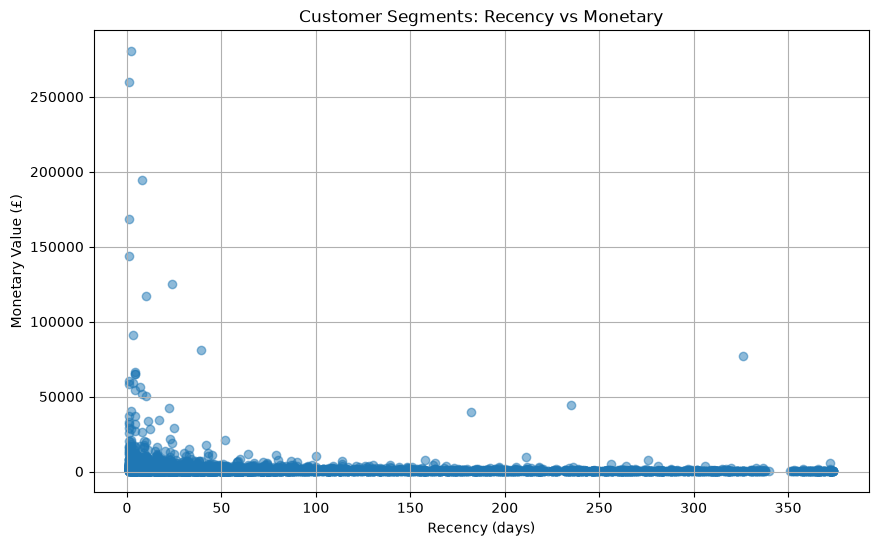

In [100]:
# Import matplotlib for visualization.
import matplotlib.pyplot as plt

# Create a scatter plot of Recency vs Monetary value.
plt.figure(figsize=(10, 6))

# Plot each customer.
plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    alpha=0.5
)

# Add axis labels and title.
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value (£)")
plt.title("Customer Segments: Recency vs Monetary")

# Add a grid to make the plot easier to read.
plt.grid(True)

# Display the plot.
plt.show()

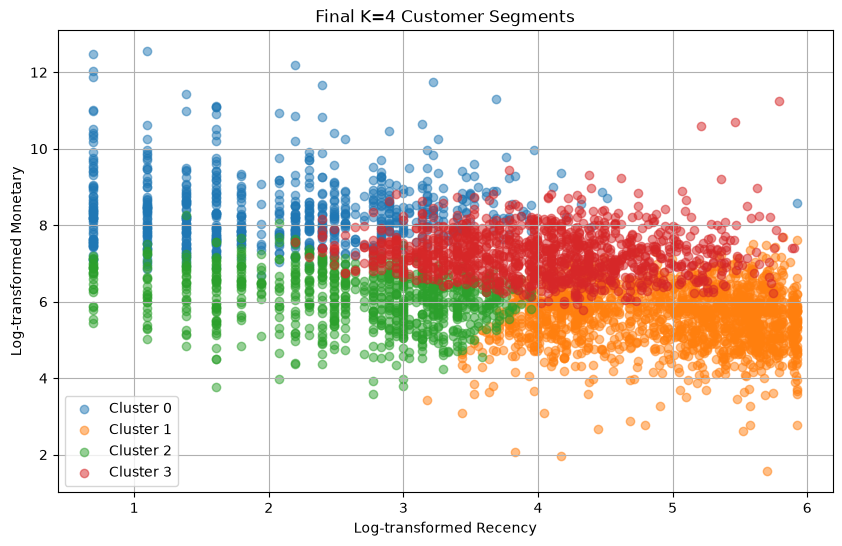

In [101]:
# Visualize the final K=4 customer clusters.
# We use the log-transformed RFM values because the original
# Monetary values are highly skewed.

plt.figure(figsize=(10, 6))

for cluster in sorted(rfm["Cluster_4"].unique()):
    
    # Select customers belonging to this cluster.
    cluster_data = rfm_log[rfm["Cluster_4"] == cluster]
    
    plt.scatter(
        cluster_data["Recency"],
        cluster_data["Monetary"],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.title("Final K=4 Customer Segments")
plt.xlabel("Log-transformed Recency")
plt.ylabel("Log-transformed Monetary")
plt.legend()
plt.grid(True)

plt.show()

In [102]:
# Compare the original rule-based baseline with the final K-Means clusters.
# This shows how customers are distributed between the two approaches.

segment_comparison = pd.crosstab(
    rfm["Baseline_Segment"],
    rfm["Cluster_4"]
)

segment_comparison


Cluster_4,0,1,2,3
Baseline_Segment,,,,
At Risk - High Value,5,0,0,170
High-Value Engaged,671,0,48,223
Low-Engagement,0,825,0,0
New / Promising,0,8,292,10
Other,37,789,497,763


In [103]:
# Recreate the DataFrame view of the already-scaled RFM data for final validation.
# We reuse rfm_scaled created earlier, so the final validation does not refit the scaler.

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled_df.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.707716
12347.0,-2.038734,1.074425,1.414903
12348.0,0.373104,0.386304,0.720024
12349.0,-0.623086,-0.955214,0.702287
12350.0,1.424558,-0.955214,-0.614514


In [104]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score for our final K=4 clustering.
# Higher values generally mean better-separated clusters.

final_silhouette = silhouette_score(
    rfm_scaled_df,
    rfm["Cluster_4"]
)

print("Final K=4 Silhouette Score:", round(final_silhouette, 4))

print("\nFinal Cluster Sizes:")
print(rfm["Cluster_4"].value_counts().sort_index())

Final K=4 Silhouette Score: 0.3375

Final Cluster Sizes:
Cluster_4
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


In [105]:
# Calculate each segment's percentage of the total customer base.

final_segment_percentage = (
    rfm["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

final_segment_percentage

Segment
Inactive / Low-Value      37.39
Moderate / Regular        26.88
Recent / Low-Frequency    19.29
High-Value Engaged        16.44
Name: proportion, dtype: float64

In [106]:
# Final validation of our customer segmentation results.

# CustomerID is the index of rfm, so we count unique index values.
print("Total customers:", rfm.index.nunique())

# Count the number of final business segments.
print("\nNumber of segments:", rfm["Segment"].nunique())

# Display the number of customers in each segment.
print("\nCustomers per segment:")
print(rfm["Segment"].value_counts())

# Check whether every customer has been assigned to a segment.
print("\nCustomers without a segment:", rfm["Segment"].isna().sum())

Total customers: 4338

Number of segments: 4

Customers per segment:
Segment
Inactive / Low-Value      1622
Moderate / Regular        1166
Recent / Low-Frequency     837
High-Value Engaged         713
Name: count, dtype: int64

Customers without a segment: 0


This project used RFM analysis and K-Means clustering to segment 4,338 customers based on purchasing behavior. After investigating and cleaning transaction-level data, customer Recency, Frequency and Monetary values were calculated. Because the RFM variables were strongly skewed, log transformation and standardization were applied before clustering. Multiple cluster counts were evaluated using the Elbow Method and Silhouette Score. Although K=2 achieved the highest silhouette score, K=4 was selected because it produced four more actionable and interpretable customer groups.

The final segmentation identified High-Value Engaged, Moderate / Regular, Recent / Low-Frequency, and Inactive / Low-Value customers. The most significant finding was that High-Value Engaged customers represented only 16.44% of the customer base but contributed 64.89% of total Monetary value. This suggests that customer retention should be a major priority, while Recent / Low-Frequency customers provide an opportunity to develop repeat purchasing behavior and Inactive / Low-Value customers can be targeted selectively through cost-efficient reactivation campaigns.

## Limitations & Assumptions

This project provides a useful customer segmentation framework, but the results should be interpreted within the following limitations:

- **Historical data:** The dataset covers customer transactions from December 2010 to December 2011. Customer behavior may have changed since this period.

- **RFM-only segmentation:** The clustering model uses only Recency, Frequency, and Monetary value. Other potentially useful information such as product preferences, country, purchase categories, or customer demographics was not included in the clustering model.

- **Transaction types:** The dataset contains special transaction descriptions such as POSTAGE, Manual, Bank Charges, and AMAZON FEE. These were inspected but retained, so Monetary value may include some non-product transaction values.

- **Cancellations and returns:** Purchase-based RFM was calculated using positive-quantity transactions. Cancellation/return behavior was therefore not modeled as a separate customer feature.

- **RFM scoring:** Quantile-based RFM scores use `rank(method="first")` to handle tied values. As a result, customers with identical raw values can sometimes receive different scores.

- **K-Means assumptions:** K-Means groups customers based on distance in the transformed and standardized RFM feature space. The method may not capture every type of customer behavior.

- **Choice of K:** K=2 achieved the highest Silhouette Score, but K=4 was selected because it provided more actionable and interpretable business segments.

- **Unsupervised learning:** There is no predefined correct customer segment label. The clusters should therefore be evaluated mainly through behavioral interpretation and business usefulness.

## Final Project Status

The customer segmentation workflow is complete: data cleaning, RFM analysis, rule-based baseline segmentation, log transformation and scaling, K-Means evaluation for K=2 to K=10, final K=4 segmentation, validation, business interpretation, and limitations.

The final K=4 solution contains 4,338 customers across four business segments. K=4 was selected using both clustering evaluation and business interpretability.


In [107]:
# Create a clean customer-level dataset for the final project.
# Each row represents one customer and contains their RFM information,
# RFM score, final K-Means cluster, and business segment.

final_customer_segments = rfm.reset_index()[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "RFM_Score",
    "Cluster_4",
    "Segment"
]]

final_customer_segments.head()

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Cluster_4,Segment
0,12346.0,326,1,77183.60,115,3,Moderate / Regular
1,12347.0,2,7,4310.00,555,0,High-Value Engaged
2,12348.0,75,4,1797.24,244,3,Moderate / Regular
3,12349.0,19,1,1757.55,414,2,Recent / Low-Frequency
4,12350.0,310,1,334.40,112,1,Inactive / Low-Value


In [108]:
# Verify the final customer-level dataset.

print("Number of rows:", len(final_customer_segments))
print("Number of unique customers:", final_customer_segments["CustomerID"].nunique())

print("\nMissing values:")
print(final_customer_segments.isna().sum())

print("\nDuplicate CustomerIDs:", final_customer_segments["CustomerID"].duplicated().sum())

print("\nCustomers per final segment:")
print(final_customer_segments["Segment"].value_counts())

Number of rows: 4338
Number of unique customers: 4338

Missing values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
RFM_Score     0
Cluster_4     0
Segment       0
dtype: int64

Duplicate CustomerIDs: 0

Customers per final segment:
Segment
Inactive / Low-Value      1622
Moderate / Regular        1166
Recent / Low-Frequency     837
High-Value Engaged         713
Name: count, dtype: int64


In [109]:
# Save the final customer segmentation dataset as a CSV file.

final_customer_segments.to_csv(
    "final_customer_segments.csv",
    index=False
)

print("Final customer segmentation dataset saved successfully.")

Final customer segmentation dataset saved successfully.


In [110]:
# Read the saved CSV back into Python.
# This verifies that the exported file can be opened correctly.

check_csv = pd.read_csv("final_customer_segments.csv")

print("CSV shape:", check_csv.shape)

print("\nCSV columns:")
print(check_csv.columns.tolist())

print("\nMissing values:")
print(check_csv.isna().sum())

print("\nFirst 5 rows:")
display(check_csv.head())

CSV shape: (4338, 7)

CSV columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Cluster_4', 'Segment']

Missing values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
RFM_Score     0
Cluster_4     0
Segment       0
dtype: int64

First 5 rows:


,CustomerID,Recency,Frequency,Monetary,RFM_Score,Cluster_4,Segment
0,12346.0,326,1,77183.60,115,3,Moderate / Regular
1,12347.0,2,7,4310.00,555,0,High-Value Engaged
2,12348.0,75,4,1797.24,244,3,Moderate / Regular
3,12349.0,19,1,1757.55,414,2,Recent / Low-Frequency
4,12350.0,310,1,334.40,112,1,Inactive / Low-Value


In [111]:
# Check that our final trained K-Means model and scaler exist.

print("K-Means model:", type(kmeans_4))
print("Scaler:", type(scaler))

K-Means model: <class 'sklearn.cluster._kmeans.KMeans'>
Scaler: <class 'sklearn.preprocessing._data.StandardScaler'>


In [112]:
# Save the final trained K-Means model.

import joblib

joblib.dump(kmeans_4, "kmeans_model.pkl")

print("K-Means model saved successfully.")

K-Means model saved successfully.


In [113]:
# Save the StandardScaler used for the final K-Means preprocessing.

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [114]:
# Verify that the saved K-Means model and scaler can be loaded correctly.

loaded_kmeans = joblib.load("kmeans_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Loaded K-Means model:", type(loaded_kmeans))
print("Loaded scaler:", type(loaded_scaler))

print("\nNumber of clusters:", loaded_kmeans.n_clusters)
print("Number of scaler features:", loaded_scaler.n_features_in_)

Loaded K-Means model: <class 'sklearn.cluster._kmeans.KMeans'>
Loaded scaler: <class 'sklearn.preprocessing._data.StandardScaler'>

Number of clusters: 4
Number of scaler features: 3


In [115]:
# Recreate the same RFM input used by the final K-Means model.

rfm_for_prediction = check_csv[[
    "Recency",
    "Frequency",
    "Monetary"
]].copy()

# Apply the same log transformation used during model training.
rfm_for_prediction_log = np.log1p(rfm_for_prediction)

# Apply the saved StandardScaler.
rfm_for_prediction_scaled = loaded_scaler.transform(
    rfm_for_prediction_log
)

# Ask the saved K-Means model to predict the cluster
# for each of the 4,338 customers.
predicted_clusters = loaded_kmeans.predict(
    rfm_for_prediction_scaled
)

# Display the first 10 predictions.
predicted_clusters[:10]

array([3, 0, 3, 2, 1, 3, 1, 1, 1, 3], dtype=int32)

In [116]:
# Compare the clusters predicted by the saved model
# with the original Cluster_4 values stored in the CSV.

matches = predicted_clusters == check_csv["Cluster_4"].values

print("Predictions match existing clusters:", matches.all())
print("Number of mismatches:", (~matches).sum())

Predictions match existing clusters: True
Number of mismatches: 0


In [117]:
# Convert the predicted cluster numbers into their business segment names
# using the same cluster-to-segment mapping used in the final model.

predicted_segments = pd.Series(predicted_clusters).map(segment_names)

# Compare the predicted segment names with the Segment column
# already stored in our final CSV.

segment_matches = (
    predicted_segments.values == check_csv["Segment"].values
)

print("Predicted segments match saved segments:", segment_matches.all())
print("Number of segment mismatches:", (~segment_matches).sum())

Predicted segments match saved segments: True
Number of segment mismatches: 0
